# Training pertTF to predict cell composition changes



You can run this tutorial on Google Colab!  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1QiWBKbMOGJwthIqZMG-BYGbengguxQ7A?usp=sharing)


Here, we demostrate how to train pertTF model using lochNESS scores. These scores can be calculated directly from Perturb-seq. In addition, gene information from pooled CRISPR screens can be incorporated into the training process (e.g., known essential genes).

Here are the steps:



*   Install pertTF
*   Load scanpy format data (.h5ad)
*   Calculate lochNESS score on the fly
*   Set up additional lochNESS scores for training (like essential genes).  

During training process, we demonstrated a two-step training:

*   The first step trains the entire model for gene expression, cell type and perturbation prediction;
*   During the second step training, the model is specifically trained on the NN for lochNESS score prediction.


The training data also leaves 1 perturbed gene out completely to test the OOD perturbation later.

# environment setup

In [1]:
!python --version


Python 3.12.12


In [2]:
# Specifically for Google Colab, install dependencies and download data
from google.colab import drive
#drive.mount('/content/drive')

import os
import sys
#%load_ext autoreload
#%autoreload 2

!pip install scanpy flash-attn --no-build-isolation

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 171.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 191.8 MB/s eta 0:00:00
  Created wheel for flash-attn: filename=flash_attn-2.8.3-cp312-cp312-linux_x86_64.whl size=256040057 sha256=f25da18657a87fc83dc1bfb8b7751b82246e9db355510226b674fd437c34b5fb
  Stored in directory: /root/.cache/pip/wheels/3d/59/46/f282c12c73dd4bb3c2e3fe199f1a0d0f8cec06df0cccfeee27
Successfully built flash-attn


# importing

In [3]:
import copy
import gc
import json
import os
from pathlib import Path
import sys
import time
import traceback
from typing import List, Tuple, Dict, Union, Optional
import warnings
import random

import torch
from anndata import AnnData
import scanpy as sc
import numpy as np
#import scvi
import wandb
from scipy.sparse import issparse
import matplotlib.pyplot as plt
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

sc.set_figure_params(figsize=(4, 4))
os.environ["KMP_WARNINGS"] = "off"
warnings.filterwarnings('ignore')

# Step 2: use pertTF github

In [4]:
# clone main branch
#!git clone https://github.com/davidliwei/pertTF.git
#sys.path.insert(0, '/content/pertTF/')

# use test pyPI
#!pip install -i https://test.pypi.org/simple/ pertTF

# use pypi
!pip install pertTF


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 13.6 MB/s eta 0:00:00


In [5]:

from perttf.model.pertTF import PerturbationTFModel
from perttf.model.config_gen import generate_config
from perttf.model.train_data_gen import produce_training_datasets
from perttf.model.train_function import train,wrapper_train,eval_testdata
from perttf.model.pert_emb import load_pert_embedding_from_gears,load_pert_embedding_to_model
from perttf.utils.preprocessor import Preprocessor

✅ Detected Flash Attention v2.


# Step 3: hyperparameter set up

In [6]:
hyperparameter_defaults = dict(
    seed=42,
    #dataset_name="PBMC_10K", # Dataset name

    save_path='/content/results/',

    dataset_name="virtual_screen_training_lochness_test_add_PS",
    do_train=True, # Flag to indicate whether to do update model parameters during training
    #load_model="/content/drive/MyDrive/Colab Notebooks/scGPT/pretrain_blood", # Path to pre-trained model
    load_model=None,
    GEPC=True,  # Gene expression modelling for cell objective
    ecs_thres=0.7,  # Elastic cell similarity objective, 0.0 to 1.0, 0.0 to disable
    dab_weight= 0.0, #2000.0, # DAR objective weight for batch correction; if has batch, set to 1.0
    this_weight = 1.0000, #1.0, # weight for predicting the expression of current cell
    next_weight = 0.0, # weight for predicting the next cell
    n_rounds = 10, # number of rounds for generating the next cell. Set to 1 for next_cell_pred_type='identity'
    next_cell_pred_type = 'lochness', # the method to predict the next cell, either "pert" (random next cell within the same cell type) or "identity" (the same cell). If "identity", set next_weight=0
    #
    ecs_weight = 1.0, # weight for predicting the similarity of cells
    cell_type_classifier=True, #  do we need the trasnformer to separate cell types?
    cell_type_classifier_weight = 1.0,
    genotype_classifier = True,
    perturbation_classifier_weight = 1.0,

    ps_weight = 0.001, # if the model involves PS prediction, use this parameter to set PS scores

    pred_lochness_next = 0.001, # newly added: pred lochness scores

    perturbation_input = False, # whether to set perturbation information as input to transformer. Set true for compression analysis; false for perturbation prediction
    CCE = False, # Contrastive cell embedding objective
    mask_ratio=0.15, # Default mask ratio
    epochs=50, # Default number of epochs for fine-tuning
    n_bins= 0, # set 0 to not process binning; default: 51, # Default number of bins for value binning in data pre-processing
    #lr=1e-4, # Default learning rate for fine-tuning
    lr=1e-3, # learning rate for learning de novo
    batch_size=128, # Default batch size for fine-tuning
    layer_size=32, # defalut 32
    nlayers=2,
    nhead=4, # if load model, batch_size, layer_size, nlayers, nhead will be ignored
    dropout=0.4, # Default dropout rate during model fine-tuning
    schedule_ratio=0.97,  # Default rate for learning rate decay
    save_eval_interval=2, # Default model evaluation interval
    log_interval=100, # Default log interval
    fast_transformer=False, # Default setting
    pre_norm=False, # Default setting
    amp=True,  # # Default setting: Automatic Mixed Precision

    do_sample_in_train = False , # sample the bernoulli in training
    ADV = False, # Adversarial training for batch correction
    adv_weight=10000,
    adv_E_delay_epochs = 2, # delay adversarial training on encoder for a few epochs
    adv_D_delay_epochs = 2,
    lr_ADV = 1e-3, # learning rate for discriminator, used when ADV is True

    DSBN =False, # True if (config.dab_weight >0 or config.ADV ) else False  # Domain-spec batchnorm; default is True
    per_seq_batch_sample =  False, # DSBN # default True
    use_batch_label = False, # default: equal to DSBN
    schedule_interval = 1,

    explicit_zero_prob = True,  # whether explicit bernoulli for zeros
    n_hvg = 3000,  # number of highly variable genes

    mask_value = -1,
    pad_value = -2,

    pad_token = "<pad>",
    cls_token = "<cls>",

    save_validation_h5ad = False, # newly added: save validation h5ad file

    sampling_mode = 'hvg',
    non_hvg_size = 0,
    fix_nonzero_prop= True,
    nonzero_prop=0.0,
    hvg_col = 'highly_variable',
    mvc_masked_train = True,
    distribution = None, # 'nb',
    use_ot = False,
    ot_params = dict(ot_top_k= 10,
             ot_epsilon = "auto",
             ot_max_dist = "auto",
             ot_epsilon_scaler= 0.01),
)



wandb configuration

In [7]:
config, run_session = generate_config(hyperparameter_defaults,wandb_mode="disabled")




wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.


{'seed': 42, 'save_path': '/content/results/', 'dataset_name': 'virtual_screen_training_lochness_test_add_PS', 'do_train': True, 'load_model': None, 'GEPC': True, 'ecs_thres': 0.7, 'dab_weight': 0.0, 'this_weight': 1.0, 'next_weight': 0.0, 'n_rounds': 10, 'next_cell_pred_type': 'lochness', 'ecs_weight': 1.0, 'cell_type_classifier': True, 'cell_type_classifier_weight': 1.0, 'genotype_classifier': True, 'perturbation_classifier_weight': 1.0, 'ps_weight': 0.001, 'pred_lochness_next': 0.001, 'perturbation_input': False, 'CCE': False, 'mask_ratio': 0.15, 'epochs': 50, 'n_bins': 0, 'lr': 0.001, 'batch_size': 128, 'layer_size': 32, 'nlayers': 2, 'nhead': 4, 'dropout': 0.4, 'schedule_ratio': 0.97, 'save_eval_interval': 2, 'log_interval': 100, 'fast_transformer': False, 'pre_norm': False, 'amp': True, 'do_sample_in_train': False, 'ADV': False, 'adv_weight': 10000, 'adv_E_delay_epochs': 2, 'adv_D_delay_epochs': 2, 'lr_ADV': 0.001, 'DSBN': False, 'per_seq_batch_sample': False, 'use_batch_label': 

In [8]:
config


{'seed': 42, 'save_path': '/content/results/', 'dataset_name': 'virtual_screen_training_lochness_test_add_PS', 'do_train': True, 'load_model': None, 'GEPC': True, 'ecs_thres': 0.7, 'dab_weight': 0.0, 'this_weight': 1.0, 'next_weight': 0.0, 'n_rounds': 10, 'next_cell_pred_type': 'lochness', 'ecs_weight': 1.0, 'cell_type_classifier': True, 'cell_type_classifier_weight': 1.0, 'genotype_classifier': True, 'perturbation_classifier_weight': 1.0, 'ps_weight': 0.001, 'pred_lochness_next': 0.001, 'perturbation_input': False, 'CCE': False, 'mask_ratio': 0.15, 'epochs': 50, 'n_bins': 0, 'lr': 0.001, 'batch_size': 128, 'layer_size': 32, 'nlayers': 2, 'nhead': 4, 'dropout': 0.4, 'schedule_ratio': 0.97, 'save_eval_interval': 2, 'log_interval': 100, 'fast_transformer': False, 'pre_norm': False, 'amp': True, 'do_sample_in_train': False, 'ADV': False, 'adv_weight': 10000, 'adv_E_delay_epochs': 2, 'adv_D_delay_epochs': 2, 'lr_ADV': 0.001, 'DSBN': False, 'per_seq_batch_sample': False, 'use_batch_label': 

In [9]:


# the following parameters have been moved to config
#DSBN =False # True if (config.dab_weight >0 or config.ADV ) else False  # Domain-spec batchnorm; default is True
#per_seq_batch_sample =  False # DSBN # default True


dataset_name = config.dataset_name
save_dir = Path(f"./save/dev_{dataset_name}-{time.strftime('%b%d-%H-%M')}/")
save_dir.mkdir(parents=True, exist_ok=True)
print(f"save to {save_dir}")
#logger = scg.logger
#scg.utils.add_file_handler(logger, save_dir / "run.log")

save to save/dev_virtual_screen_training_lochness_test_add_PS-Apr05-01-29


In [10]:
#embsize = config.layer_size
#nhead = config.nhead
#nlayers = config.nlayers
#d_hid = config.layer_size

# step 4: load scrna-seq dataset

Here we download the .h5ad file from shared files in Google Drive.

In [11]:
import os

# Install gdown if not already installed
!pip install -q gdown

file_id = '1wJgwMsr6xgDlUtYxONl4ZSX0e5RQv0ko'  #
output_filename = 'adata_pancreatic.h5ad' #

# Construct the download URL
url = f'https://drive.google.com/uc?id={file_id}'

# Download the file using gdown
!gdown --id {file_id} -O {output_filename}

if os.path.exists(output_filename):
    print(f"File '{output_filename}' downloaded successfully!")
else:
    print(f"Failed to download '{output_filename}'. Please check the file ID and permissions.")


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1wJgwMsr6xgDlUtYxONl4ZSX0e5RQv0ko
From (redirected): https://drive.google.com/uc?id=1wJgwMsr6xgDlUtYxONl4ZSX0e5RQv0ko&confirm=t&uuid=c46903ad-9192-45ed-a61c-76dcab3cf7a4
To: /content/adata_pancreatic.h5ad
100% 844M/844M [00:08<00:00, 96.4MB/s]
File 'adata_pancreatic.h5ad' downloaded successfully!


In [12]:
adata0=sc.read_h5ad(output_filename)
adata0

AnnData object with n_obs × n_vars = 111581 × 5011
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'gene', 'sgrna', 'umi_count', 'nCount_sgRNA', 'nFeature_sgRNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'time_point', 'integrated_snn_res.0.5', 'S.Score', 'G2M.Score', 'Phase', 'time', 'celltype', 'celltype_individual', 'celltype_2', 'sub.cluster', 'genotype', 'background', 'sample_clone'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'var.features', 'var.features.rank', 'vf_vst_counts.8_mean', 'vf_vst_counts.8_variance', 'vf_vst_counts.8_variance.expected', 'vf_vst_counts.8_variance.standardized', 'vf_vst_counts.8_variable', 'vf_vst_counts.8_rank', 'vf_vst_counts.9_mean', 'vf_vst_counts.9_variance', 'vf_vst_counts.9_variance.expected', 'vf_vst_counts.9_variance.standardized', 'vf_vst_counts.9_variable', 'vf_vst_counts.9_rank', 'vf_vst_counts.10_mean', 'vf_vst_counts.10_variance', 'vf_vst_counts.10_variance.expec

In [13]:
adata0.obs.genotype.value_counts(dropna=False)

,count
genotype,
WT,32693
MNX1,6451
PDX1,6207
FOXA1,5668
NKX2-2,5236
FOXA2,4896
OTUD5,3440
RFX6,3331
TLE3,3259


In [14]:
adata0.obs.celltype.value_counts(dropna=False)

,count
celltype,
ESC,21158
DE,18361
PFG,17145
PP,13388
PDP,9178
SC-EC,8785
SC-alpha,4732
Stromal,4369
SC-beta,3799


## preprocessing: binning

In [15]:
# set up the preprocessor, use the args to config the workflow
adata0.layers['GPTin'] = adata0.X.copy()

preprocessor = Preprocessor(
    use_key="GPTin",  # the key in adata.layers to use as raw data
    #filter_gene_by_counts=3,  # step 1
    #filter_cell_by_counts=False,  # step 2
    normalize_total=None,  # 3. whether to normalize the raw data and to what sum
    #result_normed_key="X_normed",  # the key in adata.layers to store the normalized data
    log1p=False,  # 4. whether to log1p the normalized data
    #result_log1p_key="X_log1p",
    subset_hvg=False,  # 5. whether to subset the raw data to highly variable genes; use n_hvg default
    hvg_flavor="seurat_v3", # if data_is_raw else "cell_ranger",
    binning=config.n_bins,  # 6. whether to bin the raw data and to what number of bins
    #binning=0,  # 6. whether to bin the raw data and to what number of bins
    result_binned_key="X_binned",  # the key in adata.layers to store the binned data
)
preprocessor(adata0, batch_key= None)


In [16]:
if config.n_bins == 0:
  adata0.layers['X_binned'] = adata0.layers['GPTin']

Because WT cells are much larger, we randomly sampled some WT cells in order to reach a balance between WT and other perturbed cells.

In [17]:

if True:
    adata0.obs.loc[adata0.obs['genotype'].isna(),'genotype']='WT'
    #adata=adata0[adata0.obs['batch']==0,:] # only use cell line data for training
    #adata_prim=adata0[adata0.obs['batch']==1,:] # a separate primary data as a validation data
    # prompt: randomly select 1000 n_obs from adata_prim
    #import random
    random_indices = np.random.rand((adata0.n_obs))
    adata= adata0[(adata0.obs.genotype != 'WT') | (random_indices <0.3)]
    adata
adata

View of AnnData object with n_obs × n_vars = 88603 × 5011
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'gene', 'sgrna', 'umi_count', 'nCount_sgRNA', 'nFeature_sgRNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'time_point', 'integrated_snn_res.0.5', 'S.Score', 'G2M.Score', 'Phase', 'time', 'celltype', 'celltype_individual', 'celltype_2', 'sub.cluster', 'genotype', 'background', 'sample_clone'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'var.features', 'var.features.rank', 'vf_vst_counts.8_mean', 'vf_vst_counts.8_variance', 'vf_vst_counts.8_variance.expected', 'vf_vst_counts.8_variance.standardized', 'vf_vst_counts.8_variable', 'vf_vst_counts.8_rank', 'vf_vst_counts.9_mean', 'vf_vst_counts.9_variance', 'vf_vst_counts.9_variance.expected', 'vf_vst_counts.9_variance.standardized', 'vf_vst_counts.9_variable', 'vf_vst_counts.9_rank', 'vf_vst_counts.10_mean', 'vf_vst_counts.10_variance', 'vf_vst_counts.10_varianc

## read GEARS embeddings and generate index

In [18]:

file_id = '1f3iFDMqH1DNT3QbUR0cyWpt_ek4huhr4'  #
output_filename = 'gear_embeddings_best_model.zip' #

# Construct the download URL
url = f'https://drive.google.com/uc?id={file_id}'

# Download the file using gdown
!gdown --id {file_id} -O {output_filename}

if os.path.exists(output_filename):
    print(f"File '{output_filename}' downloaded successfully!")
else:
    print(f"Failed to download '{output_filename}'. Please check the file ID and permissions.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1f3iFDMqH1DNT3QbUR0cyWpt_ek4huhr4
To: /content/gear_embeddings_best_model.zip
100% 7.11M/7.11M [00:00<00:00, 20.4MB/s]
File 'gear_embeddings_best_model.zip' downloaded successfully!


In [19]:
!unzip -o $output_filename -d best_model

Archive:  gear_embeddings_best_model.zip
  inflating: best_model/config.pkl   
  inflating: best_model/pert_gene_list.pkl  
  inflating: best_model/model.pt     


In [20]:


gears_path='best_model'

gears_results = load_pert_embedding_from_gears(gears_path,adata, intersect_type ='gears') # common or gears

gears_model_subset = gears_results['pert_embedding']
adata = gears_results['adata_subset']
genotype_index_gears = gears_results['genotype_index_gears']

common genes between GEARS embeddings and your adata genotypes: A1BG,AAAS,AACS,AAGAB,AAK1,AAMDC,AAMP,AAR2,AARS,AARS2,AARSD1,AASDH,AASDHPPT,AATF,ABCA7,ABCA8,ABCB10,ABCB6,ABCB7,ABCB8,ABCB9,ABCC1,ABCC10,ABCC4,ABCC5,ABCD3,ABCD4,ABCE1,ABCF1,ABCF2,ABCF3,ABCG1,ABHD10,ABHD11,ABHD12,ABHD13,ABHD14A,ABHD14B,ABHD16A,ABHD17A,ABHD17B,ABHD2,ABHD3,ABHD5,ABHD6,ABHD8,ABI1,ABI2,ABITRAM,ABL1,ABL2,ABO,ABR,ABRACL,ABRAXAS1,ABRAXAS2,ABT1,ACAA1,ACAA2,ACACA,ACAD10,ACAD8,ACAD9,ACADM,ACADS,ACADSB,ACADVL,ACAP2,ACAP3,ACAT1,ACAT2,ACBD3,ACBD5,ACBD6,ACCS,ACD,ACE,ACER3,ACHE,ACIN1,ACLY,ACO1,ACO2,ACOT12,ACOT13,ACOT7,ACOT8,ACOT9,ACOX1,ACP1,ACP2,ACP5,ACSF3,ACSL1,ACSL3,ACSL4,ACSM3,ACSS2,ACTB,ACTG1,ACTL6A,ACTN1,ACTN4,ACTR10,ACTR1A,ACTR1B,ACTR2,ACTR3,ACTR3B,ACTR3C,ACTR5,ACTR6,ACTR8,ACVR1B,ACVR2B,ACY1,ACYP1,ACYP2,ADA,ADAL,ADAM10,ADAM15,ADAM17,ADAM9,ADAMTS14,ADAMTS20,ADAMTS3,ADAMTSL4,ADAR,ADARB1,ADARB2,ADAT1,ADAT2,ADAT3,ADCK2,ADCK5,ADCY3,ADCY7,ADD1,ADD2,ADD3,ADH5,ADI1,ADIPOR1,ADIPOR2,ADK,ADNP,ADNP2,ADO,ADORA2B,ADPGK,ADPRHL2,ADR

In [21]:
adata.obs['genotype'].value_counts(dropna=False)

,count
genotype,
WT,9715
MNX1,6451
PDX1,6207
FOXA1,5668
NKX2-2,5236
FOXA2,4896
OTUD5,3440
RFX6,3331
TLE3,3259


In [22]:
#genotype_index_gears

## removing certain cell types / KOs for validation purposes

here we remove PDX1 entirely. They will be used for validation later.

In [23]:
# removing certain cell types and genotypes from the training dataset
#adata = adata [ (~adata.obs['genotype'].isin( ['PDX1','QSER1TET1'])) | (adata.obs['celltype']!='Ductal'), : ]
#adata [  (adata.obs['celltype']=='Ductal'), : ].obs['genotype'].value_counts(dropna=False)

#
adata = adata [ (~adata.obs['genotype'].isin( ['PDX1'])) , : ]

In [24]:
adata.obs['genotype'].value_counts(dropna=False)

,count
genotype,
WT,9715
MNX1,6451
FOXA1,5668
NKX2-2,5236
FOXA2,4896
OTUD5,3440
RFX6,3331
TLE3,3259
PAX6,3237


In [25]:
set(adata.obs['genotype'])

{'ARX',
 'BCOR',
 'FOXA1',
 'FOXA2',
 'GATA4',
 'GATA6',
 'GLIS3',
 'GSC',
 'HHEX',
 'HNF4A',
 'KDM2B',
 'MNX1',
 'NEUROD1',
 'NEUROG3',
 'NKX2-2',
 'OTUD5',
 'PAX6',
 'PBX1',
 'QSER1',
 'RFX6',
 'TADA2B',
 'TET1',
 'TLE3',
 'WT'}

# calculate lochNESS scores and use them to train pertTF model

Build NN (nearest neighbor) graph.

In [26]:
from perttf.model.composition_change_analysis import calculate_lonESS_score
#calculate_lonESS_score(adata0[adata0.obs.celltype=='Liver'])

# calculate lonESS score directly
if True:
  adata.obs['lonESS_score_300']=calculate_lonESS_score(adata,recalculate_nn=True,nn_name='nn_300',n_neighbors=300)



Now, calculate the lochNESS score for each perturbation (this may take some time).

In [27]:
if True:
  # To speed up, only calculate 2 genes
  #target_loci_list = ['NEUROG3','HHEX',]
  target_loci_list = ['NEUROG3','HHEX','RFX6','GATA4','GATA6','FOXA2','NEUROD1','PAX6','PBX1','TADA2B','TLE3']
  # or if you want to calculate all genes
  #target_loci_list = [ x for x in adata.obs['genotype'].unique() if x not in ['WT',]]

  target_loci_list


  for target_loci in target_loci_list:
    print(f'calculating loci {target_loci}')
    adata.obs[f'lonESS_score_{target_loci}']=calculate_lonESS_score(adata,recalculate_nn=False,nn_name='nn_300',n_neighbors=300,target_genotype=target_loci)
    #adata0.obs['lonESS_score_NGN3_100']=calculate_lonESS_score(adata0,recalculate_nn=True,nn_name='nn_100',n_neighbors=100,target_genotype='NEUROG3')
  ps_column_names=[x for x in adata.obs.columns if x.startswith('lonESS_score')]

calculating loci NEUROG3
calculating loci HHEX
calculating loci RFX6
calculating loci GATA4
calculating loci GATA6
calculating loci FOXA2
calculating loci NEUROD1
calculating loci PAX6
calculating loci PBX1
calculating loci TADA2B
calculating loci TLE3


In [28]:
# prompt: rename adata.obs column names to remove all special characters
adata.obs.genotype.value_counts(dropna=False)

,count
genotype,
WT,9715
MNX1,6451
FOXA1,5668
NKX2-2,5236
FOXA2,4896
OTUD5,3440
RFX6,3331
TLE3,3259
PAX6,3237


# Set up additional lochNESS scores entering into training process

Here we use ribosomal genes (genes whose names start from RPS or RPL) as essential genes, and train pertTF to recognize these known essential genes. The lochNESS score of these genes will be set to -1.

In [29]:
essential_gene = [x for x in genotype_index_gears.keys() if x.startswith('RPS')]
essential_gene = essential_gene + [x for x in genotype_index_gears.keys() if x.startswith('RPL')]

In [30]:
additional_ps_dict = { x: -1.0 for x in essential_gene}

In [31]:
for key in additional_ps_dict.keys():
    if key in adata0.obs.genotype.unique():
        del additional_ps_dict[key]
    if key not in genotype_index_gears.keys():
        del additional_ps_dict[key]
additional_ps_dict

{'RPS10': -1.0,
 'RPS11': -1.0,
 'RPS12': -1.0,
 'RPS13': -1.0,
 'RPS14': -1.0,
 'RPS15': -1.0,
 'RPS15A': -1.0,
 'RPS16': -1.0,
 'RPS17': -1.0,
 'RPS18': -1.0,
 'RPS19': -1.0,
 'RPS19BP1': -1.0,
 'RPS2': -1.0,
 'RPS20': -1.0,
 'RPS21': -1.0,
 'RPS23': -1.0,
 'RPS24': -1.0,
 'RPS25': -1.0,
 'RPS26': -1.0,
 'RPS27': -1.0,
 'RPS27A': -1.0,
 'RPS27L': -1.0,
 'RPS28': -1.0,
 'RPS29': -1.0,
 'RPS3': -1.0,
 'RPS3A': -1.0,
 'RPS4X': -1.0,
 'RPS5': -1.0,
 'RPS6': -1.0,
 'RPS6KA1': -1.0,
 'RPS6KA3': -1.0,
 'RPS6KA4': -1.0,
 'RPS6KB1': -1.0,
 'RPS6KB2': -1.0,
 'RPS6KC1': -1.0,
 'RPS6KL1': -1.0,
 'RPS7': -1.0,
 'RPS8': -1.0,
 'RPS9': -1.0,
 'RPSA': -1.0,
 'RPL10': -1.0,
 'RPL10A': -1.0,
 'RPL11': -1.0,
 'RPL12': -1.0,
 'RPL13': -1.0,
 'RPL13A': -1.0,
 'RPL14': -1.0,
 'RPL15': -1.0,
 'RPL17': -1.0,
 'RPL18': -1.0,
 'RPL18A': -1.0,
 'RPL19': -1.0,
 'RPL21': -1.0,
 'RPL22': -1.0,
 'RPL22L1': -1.0,
 'RPL23': -1.0,
 'RPL23A': -1.0,
 'RPL24': -1.0,
 'RPL26': -1.0,
 'RPL26L1': -1.0,
 'RPL27': -1.0,
 'RP

## prepare data for preprocessing

In [32]:
uniq_genotype=adata.obs['genotype'].unique()
uniq_genotype
ps_in_genoype = [x for x in uniq_genotype if 'lonESS_score_'+x in ps_column_names]
ps_in_genoype
ps_column_names_reduced = ['lonESS_score_'+x for x in ps_in_genoype ]

In [33]:
ps_column_names

['lonESS_score_300',
 'lonESS_score_NEUROG3',
 'lonESS_score_HHEX',
 'lonESS_score_RFX6',
 'lonESS_score_GATA4',
 'lonESS_score_GATA6',
 'lonESS_score_FOXA2',
 'lonESS_score_NEUROD1',
 'lonESS_score_PAX6',
 'lonESS_score_PBX1',
 'lonESS_score_TADA2B',
 'lonESS_score_TLE3']

In [34]:
data_produced = produce_training_datasets(adata, config,
                                          next_cell_pred=config.next_cell_pred_type,
                                          genotype_to_index= genotype_index_gears,
                                          ps_columns=ps_column_names_reduced,
                                          ps_columns_perturbed_genes = ps_in_genoype,
                                          additional_ps_dict = additional_ps_dict, # added for additional ps predictions
                                          )

#cell_type_to_index=data_produced['cell_type_to_index']
#genotype_to_index=data_produced['genotype_to_index']


#num_batch_types=data_produced['num_batch_types']
#n_perturb=data_produced['n_perturb']
# n_cls=data_produced['n_cls']

Initializing PertTFUniDataManager: Creating vocab and mappings...
sampling_mode is hvg, sampling 3000 HVGs + 0 non-HVGs for training
Initialization complete.
Creating a single train/validation split (test_size=0.2)...


In [35]:
#ps_in_genoype

In [36]:

#data_produced['adata_sorted']
data_produced['adata_sorted'].obs


,orig.ident,nCount_RNA,nFeature_RNA,gene,sgrna,umi_count,nCount_sgRNA,nFeature_sgRNA,percent.mt,RNA_snn_res.0.5,...,lonESS_score_FOXA2,lonESS_score_NEUROD1,lonESS_score_PAX6,lonESS_score_PBX1,lonESS_score_TADA2B,lonESS_score_TLE3,batch,str_batch,batch_id,genotype_next
GTTTGGAAGAGTTGCG-1_5_1,Sample_E_WT,5680.0,2702,141_WT4,141_WT4,183,183.0,1,0.737463,0,...,-0.999983,-1.000053,-0.863997,-1.000089,-0.999995,-1.000023,0,0,0,WT
AAACGCTGTTGTTGCA-1_12,Sample_J_PP,5362.0,2514,63_BCOR,63_BCOR,117,117.0,1,1.491981,0,...,-0.774910,-0.030345,-0.659560,-1.000088,-1.000171,-0.458837,0,0,0,BCOR
CCACTTGCAGAGTGTG-1_10,Sample_H_DE,5488.0,2889,31_FOXA2,31_FOXA2,58,58.0,1,1.767493,5,...,1.115805,-0.030380,-0.455256,-1.000125,-0.612617,-0.526591,0,0,0,FOXA2
ATGACCACAACTCGAT-1_11,Sample_I_PFG,5186.0,2574,103_MNX1,103_MNX1,70,70.0,1,2.333205,0,...,-0.865069,0.131235,-0.727677,-1.000002,-0.999946,0.623123,0,0,0,MNX1
CTGTACCAGGGCAGTT-1_14,Sample_L_2_3DEC,6400.0,2695,70_1_NGN3,70_1_NGN3,119,119.0,1,9.062500,5,...,-0.955007,0.939182,-0.863702,0.964203,-0.418920,0.284999,0,0,0,NEUROG3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CAAAGAATCCGATAGT-1_12,Sample_J_PP,12142.0,4739,103_MNX1,103_MNX1,47,47.0,1,1.358919,1,...,-0.864873,0.050527,-0.182830,-1.000064,-0.612487,0.555512,0,0,0,MNX1
TCCATGCCAGCTACAT-1_12,Sample_J_PP,8477.0,3943,59_TADA2B,59_TADA2B,281,281.0,1,1.439188,8,...,2.016266,-0.434568,0.021530,-0.345081,1.518053,-0.120876,0,0,0,TADA2B
CGCCATTAGTTGCTCA-1_11,Sample_I_PFG,5380.0,2664,33_FOXA1,33_FOXA1,59,59.0,1,2.063197,0,...,-0.639859,0.373606,-0.319090,-0.345219,-0.806440,0.217288,0,0,0,FOXA1
CTGCATCTCGGAATTC-1_11,Sample_I_PFG,3461.0,1791,51_FOXA1,51_FOXA1,107,107.0,1,1.213522,0,...,-0.865109,0.293014,-0.319103,-1.000089,-1.000064,0.014580,0,0,0,FOXA1


In [37]:
#data_produced['adata'].obs.loc['EC2_TTTACCAAGATCGCTT-1-r19']

In [38]:
data_produced['adata_sorted'].obs

,orig.ident,nCount_RNA,nFeature_RNA,gene,sgrna,umi_count,nCount_sgRNA,nFeature_sgRNA,percent.mt,RNA_snn_res.0.5,...,lonESS_score_FOXA2,lonESS_score_NEUROD1,lonESS_score_PAX6,lonESS_score_PBX1,lonESS_score_TADA2B,lonESS_score_TLE3,batch,str_batch,batch_id,genotype_next
GTTTGGAAGAGTTGCG-1_5_1,Sample_E_WT,5680.0,2702,141_WT4,141_WT4,183,183.0,1,0.737463,0,...,-0.999983,-1.000053,-0.863997,-1.000089,-0.999995,-1.000023,0,0,0,WT
AAACGCTGTTGTTGCA-1_12,Sample_J_PP,5362.0,2514,63_BCOR,63_BCOR,117,117.0,1,1.491981,0,...,-0.774910,-0.030345,-0.659560,-1.000088,-1.000171,-0.458837,0,0,0,BCOR
CCACTTGCAGAGTGTG-1_10,Sample_H_DE,5488.0,2889,31_FOXA2,31_FOXA2,58,58.0,1,1.767493,5,...,1.115805,-0.030380,-0.455256,-1.000125,-0.612617,-0.526591,0,0,0,FOXA2
ATGACCACAACTCGAT-1_11,Sample_I_PFG,5186.0,2574,103_MNX1,103_MNX1,70,70.0,1,2.333205,0,...,-0.865069,0.131235,-0.727677,-1.000002,-0.999946,0.623123,0,0,0,MNX1
CTGTACCAGGGCAGTT-1_14,Sample_L_2_3DEC,6400.0,2695,70_1_NGN3,70_1_NGN3,119,119.0,1,9.062500,5,...,-0.955007,0.939182,-0.863702,0.964203,-0.418920,0.284999,0,0,0,NEUROG3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CAAAGAATCCGATAGT-1_12,Sample_J_PP,12142.0,4739,103_MNX1,103_MNX1,47,47.0,1,1.358919,1,...,-0.864873,0.050527,-0.182830,-1.000064,-0.612487,0.555512,0,0,0,MNX1
TCCATGCCAGCTACAT-1_12,Sample_J_PP,8477.0,3943,59_TADA2B,59_TADA2B,281,281.0,1,1.439188,8,...,2.016266,-0.434568,0.021530,-0.345081,1.518053,-0.120876,0,0,0,TADA2B
CGCCATTAGTTGCTCA-1_11,Sample_I_PFG,5380.0,2664,33_FOXA1,33_FOXA1,59,59.0,1,2.063197,0,...,-0.639859,0.373606,-0.319090,-0.345219,-0.806440,0.217288,0,0,0,FOXA1
CTGCATCTCGGAATTC-1_11,Sample_I_PFG,3461.0,1791,51_FOXA1,51_FOXA1,107,107.0,1,1.213522,0,...,-0.865109,0.293014,-0.319103,-1.000089,-1.000064,0.014580,0,0,0,FOXA1


save data

In [39]:
#adata.obs['is_in_training']=adata.obs.index.isin(data_produced['cell_ids_train'])
adata0.obs['is_in_training']=adata0.obs.index.isin(data_produced['cell_ids_train'])
#sum(adata.obs['is_in_training'])
adata0.write_h5ad(save_dir / f'adata_original_full.h5ad')

In [40]:
#adata0.obs['is_in_training'].value_counts()

In [41]:
# delete AnnData to save memory

#del adata
#del adata0

#del adata0_full
#del adata0_full_reduced


 # Step 6: Build or Load the pre-trained scGPT model

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vocab=data_produced['vocab']

ntokens = len(vocab)  # size of vocabulary
model = PerturbationTFModel(
    data_produced['n_perturb'], #n_perturb, # number of perturbation labels
    3, # layers
    len(data_produced['ps_names']),  # 1, # ps number
    ntokens,
    config.layer_size, #embsize,
    config.nhead, #nhead,
    config.layer_size, #d_hid,
    config.nlayers, #nlayers,
    vocab=vocab,
    dropout=config.dropout,
    pad_token=config.pad_token,
    pad_value=config.pad_value,
    do_mvc=config.GEPC,
    do_dab=True if config.dab_weight >0 else False,
    use_batch_labels=config.use_batch_label,
    num_batch_labels= data_produced['num_batch_types'],#num_batch_types,
    domain_spec_batchnorm=config.DSBN,
    n_input_bins=config.n_bins,
    ecs_threshold=config.ecs_thres,
    explicit_zero_prob=config.explicit_zero_prob,
    use_fast_transformer=config.fast_transformer,
    pre_norm=config.pre_norm,
    n_cls=data_produced['n_cls'], # n_cls, # number of cell type labels
    nlayers_cls=3,
    pred_lochness_next = True if config.pred_lochness_next > 0 else False,
    ps_decoder2_nlayer = 5,
)


## load pretrained perturbation emmbeddings

In [43]:
if config.load_model is not None:
    load_pretrained(model, torch.load(model_file), verbose=False)

model = load_pert_embedding_to_model(model, gears_results['pert_embedding'])

model.to(device)
wandb.watch(model)

In [44]:
# freeze pert embedding?

#for param in model.pert_encoder.parameters():
#  param.requires_grad = False

In [45]:
print(model)


PerturbationTFModel(
  (encoder): GeneEncoder(
    (embedding): Embedding(5014, 32, padding_idx=0)
    (enc_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  )
  (value_encoder): ContinuousValueEncoder(
    (dropout): Dropout(p=0.4, inplace=False)
    (linear1): Linear(in_features=1, out_features=32, bias=True)
    (activation): ReLU()
    (linear2): Linear(in_features=32, out_features=32, bias=True)
    (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=32, bias=True)
        (dropout): Dropout(p=0.4, inplace=False)
        (linear2): Linear(in_features=32, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=

# Step 7: train

In [46]:
#if config.per_seq_batch_sample:
##    adata_prim_v = adata_prim[adata_prim.obs["batch_id"].argsort()].copy()
#else:
#    adata_prim_v = adata_prim.copy()
eval_adata_dict={
    'validation':data_produced['adata_sorted'],
#    'primary':adata_prim_v,
}


## first round of training

## set the parameters here

In [47]:
for name, param in model.named_parameters():
    if name.count('ps_decoder') >0:
        param.requires_grad = True
        print(name)
    elif name.count('ps_decoder2') >0:
        param.requires_grad = True
        print(name)
    elif name.count('pert_encoder') >0:
        param.requires_grad = False #True
        print(name)
    else:
        param.requires_grad = True

pert_encoder.embedding.weight
pert_encoder.enc_norm.weight
pert_encoder.enc_norm.bias
ps_decoder._decoder.0.weight
ps_decoder._decoder.0.bias
ps_decoder._decoder.2.weight
ps_decoder._decoder.2.bias
ps_decoder._decoder.3.weight
ps_decoder._decoder.3.bias
ps_decoder._decoder.5.weight
ps_decoder._decoder.5.bias
ps_decoder.out_layer.weight
ps_decoder.out_layer.bias
ps_decoder2._decoder.0.weight
ps_decoder2._decoder.0.bias
ps_decoder2._decoder.2.weight
ps_decoder2._decoder.2.bias
ps_decoder2._decoder.3.weight
ps_decoder2._decoder.3.bias
ps_decoder2._decoder.5.weight
ps_decoder2._decoder.5.bias
ps_decoder2._decoder.6.weight
ps_decoder2._decoder.6.bias
ps_decoder2._decoder.8.weight
ps_decoder2._decoder.8.bias
ps_decoder2._decoder.9.weight
ps_decoder2._decoder.9.bias
ps_decoder2._decoder.11.weight
ps_decoder2._decoder.11.bias
ps_decoder2.out_layer.weight
ps_decoder2.out_layer.bias


In [48]:
#config.update({'epochs': 20}, allow_val_change=True)

#config.epochs = 10

In [49]:
best_model = wrapper_train(model, config, data_produced,
                           eval_adata_dict=eval_adata_dict,
                           save_dir = save_dir)

pertTF - INFO - Active UMAP processes: 0
pertTF - INFO - | epoch   1 | 100/414 batches | lr 0.00100000 | ms/batch 283.13 | loss 11.80 | mse  0.20 | mre 121204.59 |mse_next  0.20 | mre_next 121204.59 |cls  2.38 | pert  6.95 | ps  2.59 | ps_next  0.46 |gepc  0.39 |gepc_next  0.40 |
pertTF - INFO - | epoch   1 | 200/414 batches | lr 0.00100000 | ms/batch 243.62 | loss  7.26 | mse  0.14 | mre 101192.04 |mse_next  0.14 | mre_next 101192.04 |cls  2.29 | pert  3.19 | ps  2.44 | ps_next  0.34 |gepc  0.15 |gepc_next  0.30 |
pertTF - INFO - | epoch   1 | 300/414 batches | lr 0.00100000 | ms/batch 244.50 | loss  6.93 | mse  0.13 | mre 89882.97 |mse_next  0.13 | mre_next 89882.97 |cls  2.29 | pert  2.94 | ps  2.35 | ps_next  0.18 |gepc  0.13 |gepc_next  0.30 |
pertTF - INFO - | epoch   1 | 400/414 batches | lr 0.00100000 | ms/batch 244.63 | loss  6.91 | mse  0.13 | mre 86661.32 |mse_next  0.13 | mre_next 86661.32 |cls  2.29 | pert  2.93 | ps  2.37 | ps_next  0.36 |gepc  0.13 |gepc_next  0.30 |
per

100%|██████████| 104/104 [00:15<00:00,  6.60it/s]


pertTF - INFO - Starting background process for UMAP on epoch 1 for 'validation'
pertTF - INFO - Active UMAP processes: 1
pertTF - INFO - | epoch   2 | 100/414 batches | lr 0.00097000 | ms/batch 258.54 | loss  6.91 | mse  0.13 | mre 86300.75 |mse_next  0.13 | mre_next 86300.75 |cls  2.25 | pert  2.95 | ps  2.46 | ps_next  0.37 |gepc  0.13 |gepc_next  0.31 |
pertTF - INFO - | epoch   2 | 200/414 batches | lr 0.00097000 | ms/batch 243.97 | loss  6.20 | mse  0.13 | mre 85823.13 |mse_next  0.13 | mre_next 85823.13 |cls  1.60 | pert  2.91 | ps  2.31 | ps_next  0.32 |gepc  0.13 |gepc_next  0.29 |
pertTF - INFO - | epoch   2 | 300/414 batches | lr 0.00097000 | ms/batch 245.80 | loss  5.86 | mse  0.12 | mre 84489.17 |mse_next  0.12 | mre_next 84489.17 |cls  1.28 | pert  2.89 | ps  2.28 | ps_next  0.27 |gepc  0.12 |gepc_next  0.28 |
pertTF - INFO - | epoch   2 | 400/414 batches | lr 0.00097000 | ms/batch 245.71 | loss  5.70 | mse  0.12 | mre 84250.68 |mse_next  0.12 | mre_next 84250.68 |cls  1.

100%|██████████| 104/104 [00:15<00:00,  6.76it/s]


pertTF - INFO - Starting background process for UMAP on epoch 5 for 'validation'
pertTF - INFO - Active UMAP processes: 1
pertTF - INFO - | epoch   6 | 100/414 batches | lr 0.00085873 | ms/batch 268.35 | loss  4.85 | mse  0.11 | mre 77892.30 |mse_next  0.11 | mre_next 77892.30 |cls  0.46 | pert  2.74 | ps  1.89 | ps_next  0.23 |gepc  0.12 |gepc_next  0.29 |
pertTF - INFO - | epoch   6 | 200/414 batches | lr 0.00085873 | ms/batch 243.81 | loss  4.81 | mse  0.11 | mre 77098.99 |mse_next  0.11 | mre_next 77098.99 |cls  0.46 | pert  2.73 | ps  1.84 | ps_next  0.22 |gepc  0.12 |gepc_next  0.29 |
pertTF - INFO - | epoch   6 | 300/414 batches | lr 0.00085873 | ms/batch 244.68 | loss  4.78 | mse  0.11 | mre 77513.82 |mse_next  0.11 | mre_next 77513.82 |cls  0.44 | pert  2.71 | ps  1.87 | ps_next  0.23 |gepc  0.12 |gepc_next  0.29 |
pertTF - INFO - | epoch   6 | 400/414 batches | lr 0.00085873 | ms/batch 244.04 | loss  4.76 | mse  0.11 | mre 76430.52 |mse_next  0.11 | mre_next 76430.52 |cls  0.

...

pertTF - INFO - Starting background process for UMAP on epoch 41 for 'validation'
pertTF - INFO - Active UMAP processes: 1
pertTF - INFO - | epoch  42 | 100/414 batches | lr 0.00028684 | ms/batch 260.16 | loss  6.88 | mse  0.16 | mre 102004.85 |mse_next  0.16 | mre_next 102004.85 |cls  2.17 | pert  2.93 | ps  2.39 | ps_next  0.20 |gepc  0.13 |gepc_next  0.34 |
pertTF - INFO - | epoch  42 | 200/414 batches | lr 0.00028684 | ms/batch 244.70 | loss  6.76 | mse  0.16 | mre 100445.56 |mse_next  0.16 | mre_next 100445.56 |cls  2.09 | pert  2.91 | ps  2.41 | ps_next  0.30 |gepc  0.13 |gepc_next  0.34 |
pertTF - INFO - | epoch  42 | 300/414 batches | lr 0.00028684 | ms/batch 244.44 | loss  6.71 | mse  0.16 | mre 101363.56 |mse_next  0.16 | mre_next 101363.56 |cls  2.06 | pert  2.89 | ps  2.37 | ps_next  0.26 |gepc  0.13 |gepc_next  0.34 |
pertTF - INFO - | epoch  42 | 400/414 batches | lr 0.00028684 | ms/batch 243.72 | loss  6.71 | mse  0.16 | mre 101236.25 |mse_next  0.16 | mre_next 101236.25

100%|██████████| 104/104 [00:19<00:00,  5.42it/s]


pertTF - INFO - Starting background process for UMAP on epoch 45 for 'validation'
pertTF - INFO - Active UMAP processes: 1
pertTF - INFO - | epoch  46 | 100/414 batches | lr 0.00025394 | ms/batch 270.16 | loss  6.94 | mse  0.17 | mre 94806.45 |mse_next  0.17 | mre_next 94806.45 |cls  2.17 | pert  2.96 | ps  2.40 | ps_next  0.23 |gepc  0.14 |gepc_next  0.34 |
pertTF - INFO - | epoch  46 | 200/414 batches | lr 0.00025394 | ms/batch 247.70 | loss  6.65 | mse  0.17 | mre 103030.58 |mse_next  0.17 | mre_next 103030.58 |cls  1.99 | pert  2.88 | ps  2.41 | ps_next  0.25 |gepc  0.14 |gepc_next  0.34 |
pertTF - INFO - | epoch  46 | 300/414 batches | lr 0.00025394 | ms/batch 244.54 | loss  6.67 | mse  0.17 | mre 101883.22 |mse_next  0.17 | mre_next 101883.22 |cls  2.01 | pert  2.89 | ps  2.31 | ps_next  0.25 |gepc  0.14 |gepc_next  0.34 |
pertTF - INFO - | epoch  46 | 400/414 batches | lr 0.00025394 | ms/batch 244.13 | loss  6.68 | mse  0.17 | mre 102210.03 |mse_next  0.17 | mre_next 102210.03 |

100%|██████████| 104/104 [00:19<00:00,  5.44it/s]


pertTF - INFO - Starting background process for UMAP on epoch 49 for 'validation'
pertTF - INFO - Active UMAP processes: 1
pertTF - INFO - | epoch  50 | 100/414 batches | lr 0.00022481 | ms/batch 271.31 | loss  6.72 | mse  0.17 | mre 105973.54 |mse_next  0.17 | mre_next 105973.54 |cls  2.01 | pert  2.92 | ps  2.35 | ps_next  0.23 |gepc  0.14 |gepc_next  0.35 |
pertTF - INFO - | epoch  50 | 200/414 batches | lr 0.00022481 | ms/batch 245.24 | loss  6.62 | mse  0.17 | mre 103386.11 |mse_next  0.17 | mre_next 103386.11 |cls  1.97 | pert  2.88 | ps  2.41 | ps_next  0.20 |gepc  0.14 |gepc_next  0.34 |
pertTF - INFO - | epoch  50 | 300/414 batches | lr 0.00022481 | ms/batch 243.62 | loss  6.62 | mse  0.17 | mre 104444.57 |mse_next  0.17 | mre_next 104444.57 |cls  1.95 | pert  2.89 | ps  2.23 | ps_next  0.17 |gepc  0.14 |gepc_next  0.34 |
pertTF - INFO - | epoch  50 | 400/414 batches | lr 0.00022481 | ms/batch 244.51 | loss  6.62 | mse  0.17 | mre 101870.88 |mse_next  0.17 | mre_next 101870.88

## second round of training

### evaluation

Use the genes not in the training dataset as a validation (e.g., MRPS genes).

In [50]:
best_model_copy = copy.deepcopy(best_model)
adata_testrun=data_produced['adata_sorted'].copy()
adata_testrun=adata_testrun[adata_testrun.obs.genotype.isin(['WT'])]
adata_testrun

View of AnnData object with n_obs × n_vars = 1899 × 5011
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'gene', 'sgrna', 'umi_count', 'nCount_sgRNA', 'nFeature_sgRNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'time_point', 'integrated_snn_res.0.5', 'S.Score', 'G2M.Score', 'Phase', 'time', 'celltype', 'celltype_individual', 'celltype_2', 'sub.cluster', 'genotype', 'background', 'sample_clone', 'lonESS_score_300', 'lonESS_score_NEUROG3', 'lonESS_score_HHEX', 'lonESS_score_RFX6', 'lonESS_score_GATA4', 'lonESS_score_GATA6', 'lonESS_score_FOXA2', 'lonESS_score_NEUROD1', 'lonESS_score_PAX6', 'lonESS_score_PBX1', 'lonESS_score_TADA2B', 'lonESS_score_TLE3', 'batch', 'str_batch', 'batch_id', 'genotype_next'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'var.features', 'var.features.rank', 'vf_vst_counts.8_mean', 'vf_vst_counts.8_variance', 'vf_vst_counts.8_variance.expected', 'vf_vst_counts.8_variance.standardized', '

In [51]:
[x for x in genotype_index_gears.keys() if x.startswith('MRPL')]

['MRPL1',
 'MRPL10',
 'MRPL11',
 'MRPL13',
 'MRPL14',
 'MRPL15',
 'MRPL16',
 'MRPL17',
 'MRPL18',
 'MRPL19',
 'MRPL2',
 'MRPL20',
 'MRPL21',
 'MRPL22',
 'MRPL23',
 'MRPL24',
 'MRPL27',
 'MRPL28',
 'MRPL3',
 'MRPL30',
 'MRPL32',
 'MRPL33',
 'MRPL34',
 'MRPL35',
 'MRPL36',
 'MRPL37',
 'MRPL38',
 'MRPL39',
 'MRPL4',
 'MRPL40',
 'MRPL41',
 'MRPL42',
 'MRPL43',
 'MRPL44',
 'MRPL45',
 'MRPL46',
 'MRPL47',
 'MRPL48',
 'MRPL49',
 'MRPL50',
 'MRPL51',
 'MRPL52',
 'MRPL53',
 'MRPL54',
 'MRPL55',
 'MRPL58',
 'MRPL9']

In [52]:
target_pred_gene='RPL4' # ribosomal gene: should be -2
target_pred_gene='RPS5' # ribosomal gene: should be -2
target_pred_gene='MRPL1' # other ribosomal gene not in training
target_pred_gene='MRPS5' # other ribosomal gene not in training
import pandas as pd

# Ensure that 'WT' and target_pred_gene are in the categories of 'genotype_next'
if pd.api.types.is_categorical_dtype(adata_testrun.obs.genotype_next):
  new_categories = list(adata_testrun.obs['genotype_next'].cat.categories)
  if 'WT' not in new_categories:
      new_categories.append('WT')
  if target_pred_gene not in new_categories:
      new_categories.append(target_pred_gene)
  adata_testrun.obs['genotype_next'] = adata_testrun.obs['genotype_next'].cat.set_categories(new_categories)


adata_testrun.obs.loc[adata_testrun.obs['genotype'].isin(['WT']), 'genotype_next'] = np.random.choice([target_pred_gene,'WT'], size = sum(adata_testrun.obs['genotype'].isin(['WT'])))
adata_testrun.obs.loc[adata_testrun.obs['genotype']=='WT' ,'genotype_next'].value_counts()

,count
genotype_next,
MRPS5,955
WT,944


In [53]:
data_produced.keys()

dict_keys(['genes', 'gene_ids', 'vocab', 'num_batch_types', 'num_cell_types', 'num_genotypes', 'cell_type_to_index', 'genotype_to_index', 'ps_names', 'train_loader', 'valid_loader', 'train_data', 'valid_data', 'cell_ids_train', 'adata_sorted', 'adata_manager', 'n_perturb', 'n_cls'])

In [54]:
best_model_copy.to(device)
adata_eva = eval_testdata(best_model_copy, adata_testrun,  data_produced['gene_ids'],
                             train_data_dict=data_produced,
                             config = config)


pertTF - INFO - 5011 genes shared between model vocab's 5014 and anndata's 5011 genes
pertTF - INFO - Evaluating data using 5000 tokens for each cell


100%|██████████| 15/15 [00:02<00:00,  6.75it/s]


In [55]:
#adata_eva.obsm['ps_pred_next']
adata_testrun.obs.genotype_next.value_counts()
adata_eva.obs.genotype_next.value_counts()

,count
genotype_next,
MRPS5,955
WT,944


In [56]:
zzt=adata_testrun.copy()
zzt.obs.genotype_next.value_counts()

,count
genotype_next,
MRPS5,955
WT,944


In [57]:
adata_eva.obs

,orig.ident,nCount_RNA,nFeature_RNA,gene,sgrna,umi_count,nCount_sgRNA,nFeature_sgRNA,percent.mt,RNA_snn_res.0.5,...,lonESS_score_TADA2B,lonESS_score_TLE3,batch,str_batch,batch_id,genotype_next,predicted_genotype,genotype_id,predicted_celltype,celltype_id
GTTTGGAAGAGTTGCG-1_5_1,Sample_E_WT,5680.0,2702,141_WT4,141_WT4,183,183.0,1,0.737463,0,...,-0.999995,-1.000023,0,0,0,MRPS5,WT,9853,PP,2
CAGCCAGTCCGCTAGG-1_3,Sample_B_WT,8938.0,3887,133_WT111,133_WT111,62,62.0,1,3.386882,1,...,-0.612625,-0.053012,0,0,0,WT,WT,9853,SC-EC,7
CACTGAACAGACCGCT-1_3,Sample_B_WT,792.0,543,135_WT111,135_WT111,19,19.0,1,2.498409,5,...,-1.000144,-0.594226,0,0,0,MRPS5,WT,9853,EnP,11
ACTTCGCTCAACGCTA-1_3,Sample_B_WT,8497.0,4079,135_WT111,135_WT111,40,40.0,1,5.253322,8,...,-1.000180,-0.999988,0,0,0,WT,WT,9853,EnP,7
TTCGCTGAGTCGCTAT-1_12,Sample_J_PP,11861.0,4571,47_WT,47_WT,143,143.0,1,1.913835,0,...,-0.612592,0.217479,0,0,0,MRPS5,FOXA1,9853,PP,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AGGTCTACAAGCGCAA-1_3,Sample_B_WT,4443.0,2708,133_WT111,133_WT111,74,74.0,1,4.047853,0,...,-1.000045,-1.000134,0,0,0,MRPS5,WT,9853,EnP,11
TTTGATCGTAGGCAGT-1_4_1,Sample_D_WT,5460.0,2672,140_WT4,140_WT4,107,107.0,1,0.802855,3,...,-0.612552,-0.526564,0,0,0,WT,WT,9853,PP,2
GGCTTGGGTTGGGTTT-1_6_1,Sample_F_WT,8585.0,3720,150_WT4,150_WT4,143,143.0,1,2.084488,6,...,-0.999760,-0.999965,0,0,0,MRPS5,WT,9853,PGT,5
AATAGAGTCATTCTTG-1_4_1,Sample_D_WT,10303.0,4257,140_WT4,140_WT4,132,132.0,1,1.131328,0,...,-0.806360,-0.932346,0,0,0,WT,WT,9853,PP,2


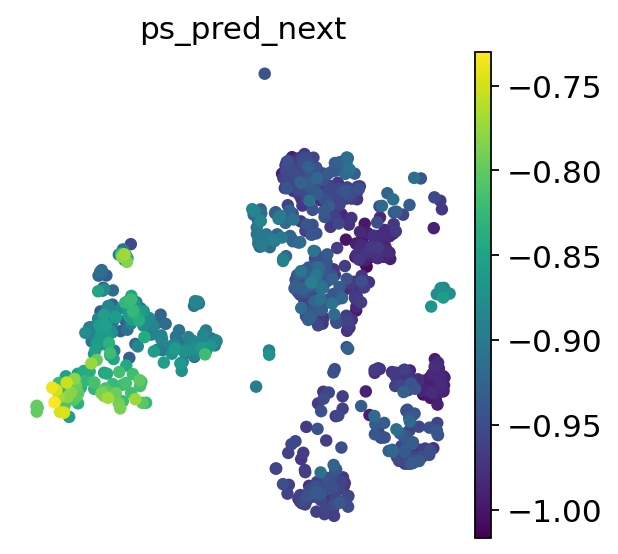

In [58]:
adata_eva.obs['ps_pred_next']=adata_eva.obsm['ps_pred_next']
#sc.pl.umap(adata_eva[adata_eva.obs.genotype_next=='WT'], color=[ "ps_pred_next",],frameon=False,)
adata_eva_next_nonwt=adata_eva[adata_eva.obs.genotype_next!='WT']
sc.pl.umap(adata_eva_next_nonwt, color=[ "ps_pred_next",],frameon=False,)



Quantiles of ps_pred_next:
[-1.01660156 -0.97167969 -0.95166016 -0.91259766 -0.72998047]


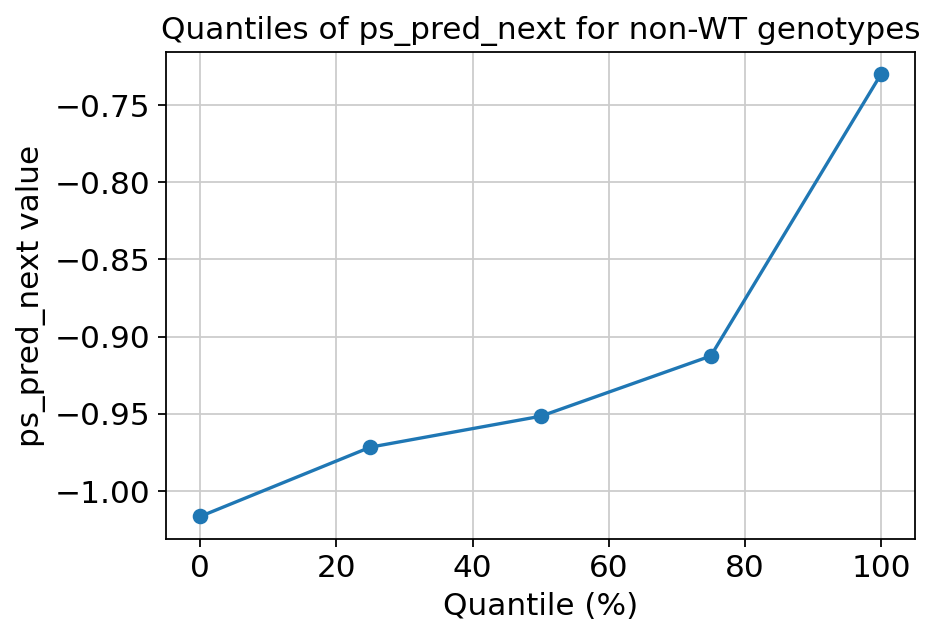

In [59]:
# calculate and plot the 0, 25, 50, 75 and 100 quantile of adata_eva_next_nonwt.obs['ps_pred_next']

quantiles = np.quantile(adata_eva_next_nonwt.obs['ps_pred_next'], [0, 0.25, 0.5, 0.75, 1])
print("Quantiles of ps_pred_next:")
print(quantiles)

plt.figure(figsize=(6, 4))
plt.plot([0, 25, 50, 75, 100], quantiles, marker='o')
plt.xlabel("Quantile (%)")
plt.ylabel("ps_pred_next value")
plt.title("Quantiles of ps_pred_next for non-WT genotypes")
plt.grid(True)
plt.show()

### train again

In [60]:
for name, param in best_model.named_parameters():
    if name.count('ps_decoder') >0:
        param.requires_grad = True
        print(name)
    elif name.count('ps_decoder2') >0:
        param.requires_grad = True
        print(name)
    elif name.count('pert_encoder') >0:
        param.requires_grad = False #True
        print(name)
    else:
        param.requires_grad = False

pert_encoder.embedding.weight
pert_encoder.enc_norm.weight
pert_encoder.enc_norm.bias
ps_decoder._decoder.0.weight
ps_decoder._decoder.0.bias
ps_decoder._decoder.2.weight
ps_decoder._decoder.2.bias
ps_decoder._decoder.3.weight
ps_decoder._decoder.3.bias
ps_decoder._decoder.5.weight
ps_decoder._decoder.5.bias
ps_decoder.out_layer.weight
ps_decoder.out_layer.bias
ps_decoder2._decoder.0.weight
ps_decoder2._decoder.0.bias
ps_decoder2._decoder.2.weight
ps_decoder2._decoder.2.bias
ps_decoder2._decoder.3.weight
ps_decoder2._decoder.3.bias
ps_decoder2._decoder.5.weight
ps_decoder2._decoder.5.bias
ps_decoder2._decoder.6.weight
ps_decoder2._decoder.6.bias
ps_decoder2._decoder.8.weight
ps_decoder2._decoder.8.bias
ps_decoder2._decoder.9.weight
ps_decoder2._decoder.9.bias
ps_decoder2._decoder.11.weight
ps_decoder2._decoder.11.bias
ps_decoder2.out_layer.weight
ps_decoder2.out_layer.bias


In [61]:
for name, param in best_model.named_parameters():
    if name == 'cls_decoder.out_layer.bias' or name == 'ps_decoder.out_layer.bias':
        print(name)
        print(param)

cls_decoder.out_layer.bias
Parameter containing:
tensor([ 0.2303,  0.2375,  0.1380,  0.0712,  0.1374, -0.1807, -0.0865, -0.0238,
         0.0091, -0.3410,  0.0678,  0.0728, -0.3172, -0.1578], device='cuda:0')
ps_decoder.out_layer.bias
Parameter containing:
tensor([-0.0603, -0.0167, -0.0438,  0.0543, -0.2003, -0.0888,  0.1542,  0.0247,
         0.1942,  0.0303, -0.0667], device='cuda:0', requires_grad=True)


updating config: retrain ps and lochness module to make it more accurate

In [62]:
config.update({'epochs':20, 'lr':1e-3, 'pred_lochness_next':100, 'ps_weight':10,}, allow_val_change=True)

#config.epochs = 10

In [63]:
save_dir2=save_dir / 'second_round'
save_dir2.mkdir(exist_ok=True, parents=True)

In [64]:
best_model = wrapper_train(best_model, config, data_produced,
                           eval_adata_dict=eval_adata_dict,
                           save_dir = save_dir2)

pertTF - INFO - Active UMAP processes: 0
pertTF - INFO - | epoch   1 | 100/414 batches | lr 0.00100000 | ms/batch 103.12 | loss 43.13 | mse  0.11 | mre 73131.58 |mse_next  0.11 | mre_next 73131.58 |cls  0.34 | pert  2.24 | ps  1.21 | ps_next  0.27 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch   1 | 200/414 batches | lr 0.00100000 | ms/batch 90.77 | loss 36.07 | mse  0.11 | mre 72499.07 |mse_next  0.11 | mre_next 72499.07 |cls  0.33 | pert  2.23 | ps  1.14 | ps_next  0.21 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch   1 | 300/414 batches | lr 0.00100000 | ms/batch 90.99 | loss 35.07 | mse  0.11 | mre 72431.50 |mse_next  0.11 | mre_next 72431.50 |cls  0.34 | pert  2.24 | ps  1.12 | ps_next  0.20 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch   1 | 400/414 batches | lr 0.00100000 | ms/batch 91.16 | loss 32.65 | mse  0.11 | mre 72426.82 |mse_next  0.11 | mre_next 72426.82 |cls  0.32 | pert  2.25 | ps  1.09 | ps_next  0.18 |gepc  0.11 |gepc_next  0.32 |
pertTF - I

100%|██████████| 104/104 [00:15<00:00,  6.76it/s]


pertTF - INFO - Starting background process for UMAP on epoch 1 for 'validation'
pertTF - INFO - Active UMAP processes: 1
pertTF - INFO - | epoch   2 | 100/414 batches | lr 0.00097000 | ms/batch 107.68 | loss 38.43 | mse  0.11 | mre 73102.82 |mse_next  0.11 | mre_next 73102.82 |cls  0.33 | pert  2.25 | ps  1.08 | ps_next  0.23 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch   2 | 200/414 batches | lr 0.00097000 | ms/batch 91.14 | loss 28.57 | mse  0.11 | mre 72420.51 |mse_next  0.11 | mre_next 72420.51 |cls  0.34 | pert  2.24 | ps  1.04 | ps_next  0.14 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch   2 | 300/414 batches | lr 0.00097000 | ms/batch 91.97 | loss 32.67 | mse  0.11 | mre 72338.83 |mse_next  0.11 | mre_next 72338.83 |cls  0.32 | pert  2.24 | ps  1.02 | ps_next  0.18 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch   2 | 400/414 batches | lr 0.00097000 | ms/batch 92.01 | loss 33.52 | mse  0.11 | mre 72446.61 |mse_next  0.11 | mre_next 72446.61 |cls  0.32 

100%|██████████| 104/104 [00:17<00:00,  6.00it/s]


pertTF - INFO - Starting background process for UMAP on epoch 5 for 'validation'
pertTF - INFO - Active UMAP processes: 1
pertTF - INFO - | epoch   6 | 100/414 batches | lr 0.00085873 | ms/batch 117.12 | loss 34.31 | mse  0.11 | mre 73183.97 |mse_next  0.11 | mre_next 73183.97 |cls  0.33 | pert  2.27 | ps  0.94 | ps_next  0.21 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch   6 | 200/414 batches | lr 0.00085873 | ms/batch 91.70 | loss 25.21 | mse  0.11 | mre 72344.81 |mse_next  0.11 | mre_next 72344.81 |cls  0.33 | pert  2.24 | ps  0.95 | ps_next  0.12 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch   6 | 300/414 batches | lr 0.00085873 | ms/batch 91.03 | loss 27.03 | mse  0.11 | mre 72389.32 |mse_next  0.11 | mre_next 72389.32 |cls  0.33 | pert  2.22 | ps  0.93 | ps_next  0.14 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch   6 | 400/414 batches | lr 0.00085873 | ms/batch 91.44 | loss 24.54 | mse  0.11 | mre 72326.61 |mse_next  0.11 | mre_next 72326.61 |cls  0.33 

...

pertTF - INFO - Starting background process for UMAP on epoch 9 for 'validation'
pertTF - INFO - Active UMAP processes: 1
pertTF - INFO - | epoch  10 | 100/414 batches | lr 0.00076023 | ms/batch 116.63 | loss 29.01 | mse  0.11 | mre 73272.41 |mse_next  0.11 | mre_next 73272.41 |cls  0.34 | pert  2.26 | ps  0.93 | ps_next  0.15 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch  10 | 200/414 batches | lr 0.00076023 | ms/batch 91.78 | loss 29.39 | mse  0.11 | mre 72579.41 |mse_next  0.11 | mre_next 72579.41 |cls  0.34 | pert  2.23 | ps  0.92 | ps_next  0.16 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch  10 | 300/414 batches | lr 0.00076023 | ms/batch 91.88 | loss 29.20 | mse  0.11 | mre 72397.98 |mse_next  0.11 | mre_next 72397.98 |cls  0.34 | pert  2.23 | ps  0.88 | ps_next  0.16 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch  10 | 400/414 batches | lr 0.00076023 | ms/batch 91.37 | loss 34.32 | mse  0.11 | mre 72310.08 |mse_next  0.11 | mre_next 72310.08 |cls  0.32 

100%|██████████| 104/104 [00:17<00:00,  6.01it/s]


pertTF - INFO - Starting background process for UMAP on epoch 13 for 'validation'
pertTF - INFO - Active UMAP processes: 1
pertTF - INFO - | epoch  14 | 100/414 batches | lr 0.00067303 | ms/batch 106.12 | loss 27.26 | mse  0.11 | mre 73069.17 |mse_next  0.11 | mre_next 73069.17 |cls  0.34 | pert  2.27 | ps  0.87 | ps_next  0.14 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch  14 | 200/414 batches | lr 0.00067303 | ms/batch 91.54 | loss 24.98 | mse  0.11 | mre 72589.95 |mse_next  0.11 | mre_next 72589.95 |cls  0.32 | pert  2.23 | ps  0.88 | ps_next  0.12 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch  14 | 300/414 batches | lr 0.00067303 | ms/batch 90.91 | loss 25.12 | mse  0.11 | mre 72323.99 |mse_next  0.11 | mre_next 72323.99 |cls  0.33 | pert  2.22 | ps  0.88 | ps_next  0.12 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch  14 | 400/414 batches | lr 0.00067303 | ms/batch 91.06 | loss 25.67 | mse  0.11 | mre 72394.06 |mse_next  0.11 | mre_next 72394.06 |cls  0.33

100%|██████████| 104/104 [00:19<00:00,  5.41it/s]


pertTF - INFO - Starting background process for UMAP on epoch 17 for 'validation'
pertTF - INFO - Active UMAP processes: 1
pertTF - INFO - | epoch  18 | 100/414 batches | lr 0.00059583 | ms/batch 119.71 | loss 22.99 | mse  0.11 | mre 73021.14 |mse_next  0.11 | mre_next 73021.14 |cls  0.34 | pert  2.25 | ps  0.86 | ps_next  0.10 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch  18 | 200/414 batches | lr 0.00059583 | ms/batch 91.61 | loss 27.44 | mse  0.11 | mre 72361.25 |mse_next  0.11 | mre_next 72361.25 |cls  0.33 | pert  2.24 | ps  0.84 | ps_next  0.15 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch  18 | 300/414 batches | lr 0.00059583 | ms/batch 91.25 | loss 22.62 | mse  0.11 | mre 72605.02 |mse_next  0.11 | mre_next 72605.02 |cls  0.32 | pert  2.23 | ps  0.88 | ps_next  0.10 |gepc  0.11 |gepc_next  0.32 |
pertTF - INFO - | epoch  18 | 400/414 batches | lr 0.00059583 | ms/batch 91.53 | loss 24.54 | mse  0.11 | mre 72451.45 |mse_next  0.11 | mre_next 72451.45 |cls  0.33

In [65]:
for name, param in best_model.named_parameters():
    if name == 'cls_decoder.out_layer.bias' or name == 'ps_decoder.out_layer.bias':
        print(name)
        print(param)

cls_decoder.out_layer.bias
Parameter containing:
tensor([ 0.2303,  0.2375,  0.1380,  0.0712,  0.1374, -0.1807, -0.0865, -0.0238,
         0.0091, -0.3410,  0.0678,  0.0728, -0.3172, -0.1578], device='cuda:0')
ps_decoder.out_layer.bias
Parameter containing:
tensor([-0.0402,  0.0466,  0.0710,  0.0971, -0.2969, -0.0136,  0.2652,  0.0344,
         0.2926, -0.0466, -0.1504], device='cuda:0', requires_grad=True)


# Displaying the results of lochNESS score prediction

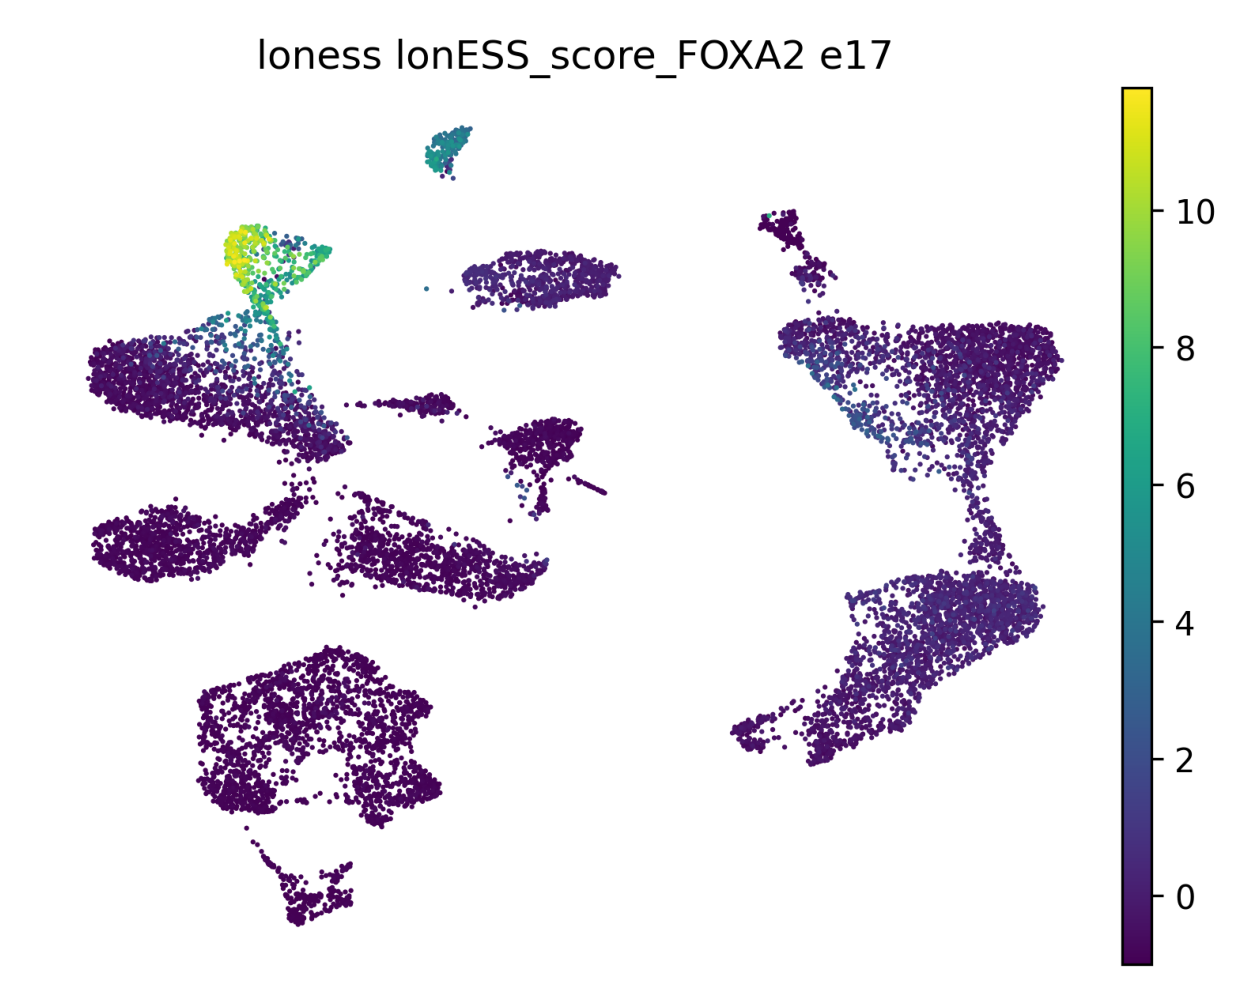

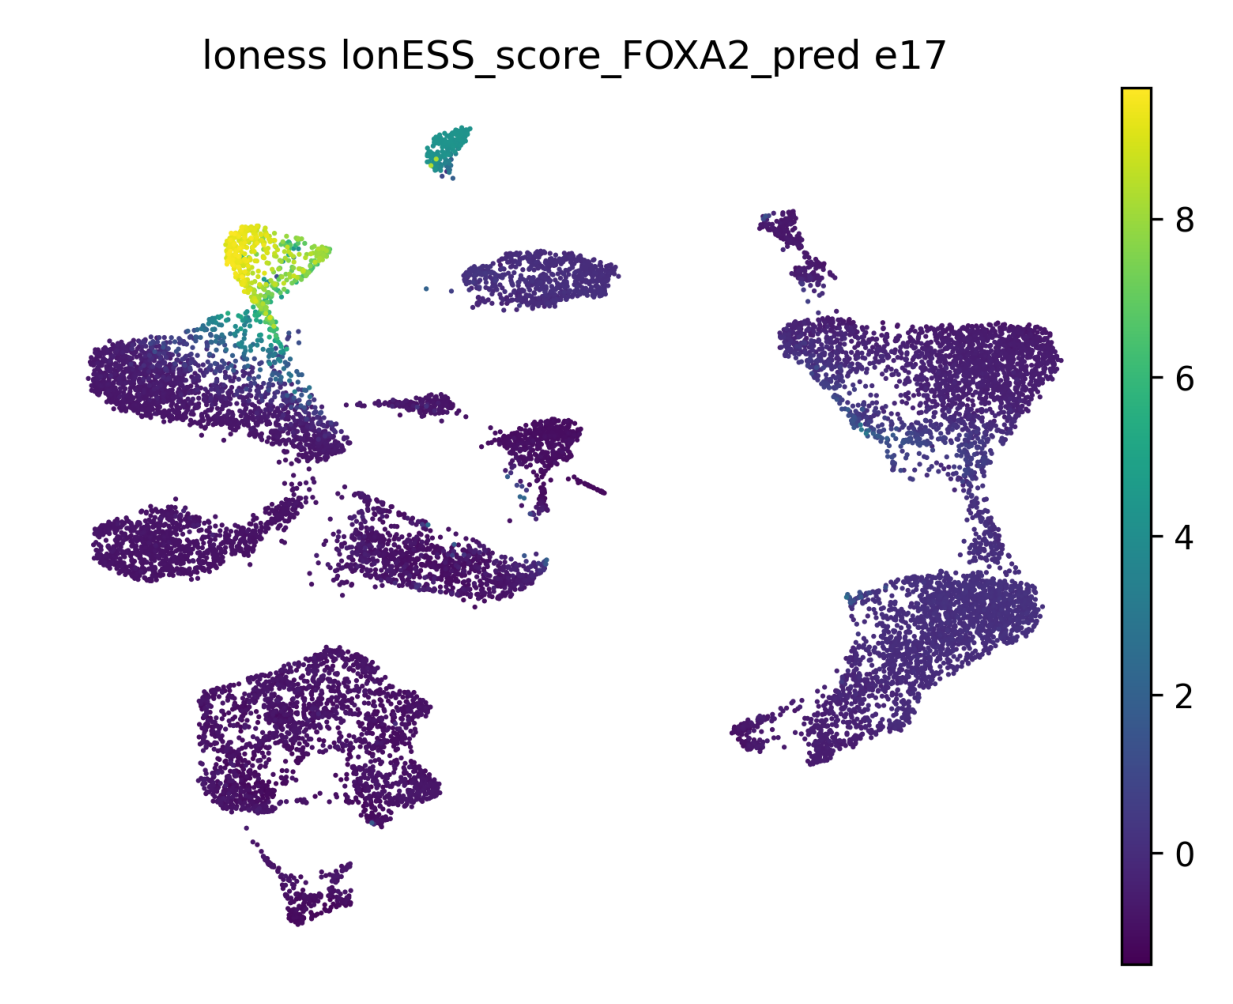

In [76]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_path = '/content/results/second_round/e17_imgs/validation_loness_lonESS_score_FOXA2_e17.png'
img = mpimg.imread(image_path)
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off') # Hide axes ticks and labels
plt.show()

image_path = '/content/results/second_round/e17_imgs/validation_loness_lonESS_score_FOXA2_pred_e17.png'
img = mpimg.imread(image_path)
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off') # Hide axes ticks and labels
plt.show()


# Cleaning up

In [66]:
#raise Exception('Stop here')

In [67]:
artifact = wandb.Artifact(f"best_model", type="model")
glob_str = os.path.join(save_dir, "best_model.pt")
if os.path.exists(glob_str):
    artifact.add_file(glob_str)
run_session.log_artifact(artifact)

run_session.finish()
wandb.finish()
gc.collect()

19365

In [68]:
!cp -r $save_dir "$config.save_path"


In [69]:
config.save_path

'/content/results/'

In [70]:
save_dir

PosixPath('save/dev_virtual_screen_training_lochness_test_add_PS-Apr05-01-29')

In [71]:
!tar pczf '{save_dir}.tar.gz' $save_dir

Optional: save all the files to Google Drive

In [72]:
if True:
    drive.mount('/content/drive')
    !cp '{save_dir}.tar.gz' '/content/drive/MyDrive/Colab Notebooks/scGPT/perttf_tutorial/public/virtual_screen/data'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
